In [1]:

import os, sys

from pathlib import Path
from xnemogcm import open_nemo_and_domain_cfg, get_metrics
from xnemogcm.metrics import compute_missing_metrics
import xgcm
import xarray as xr
import xnemogcm as xn
import numbers
import matplotlib.pyplot as plt
import numpy as np
import xesmf

# gsw and gsw-xarray packages
import gsw
import gsw_xarray as xgsw

import pandas as pd
import glob
import cartopy.crs as ccrs

import time as time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator

from pyCDFTOOLS import analysis, in_out

import warnings
warnings.filterwarnings("ignore", category=FutureWarning) 


In [2]:

T_grid = ["x_c", "y_c", "z_c"]
T_grid_h = ["x_c", "y_c"]
U_grid = ["x_f", "y_c", "z_c"]
V_grid = ["x_c", "y_f", "z_c"]
W_grid = ["x_c", "y_c", "z_f"]
F_grid = ["x_f", "y_f", "z_c"]
UW_grid = ["x_f", "y_c", "z_f"]
VW_grid = ["x_c", "y_f", "z_f"]
FW_grid = ["x_f", "y_f", "z_f"]

def check_Z_grid(dsattr):
    '''
    Check the where the data (dsattr) are placed in Z-direction.
    Return var_T, var_W and z_ind
    '''
    var_T, var_W, z_ind = False, False, None
    var_T_name, var_W_name = "z_c", "z_f"

    if var_T_name in list(dsattr.coords):
        var_T = True
        z_ind = dsattr[var_T_name].values.astype('int')
    elif var_W_name in list(dsattr.coords):
        var_W = True
        z_ind = (dsattr[var_W_name].values + 1).astype('int')  # because shifted down

    return var_T, var_W, z_ind

def check_type_grid(da: xr.DataArray,
                    da_name: str, grid_name: str,
                    check_type: object | tuple,
                    check_grid: list | tuple):
    assert isinstance(da, xr.DataArray)
    assert isinstance(check_type, (object, tuple))
    assert isinstance(check_grid, (list, tuple))
    assert isinstance(da_name, str) and isinstance(grid_name, str)

    assert isinstance(da, check_type), \
        f"{da_name} is not one of the types: {check_type} !"
    assert all(x in list(da.coords) for x in check_grid), \
        f"{da_name} not define on {grid_name} grid"

def contourf_check(var): 
    plt.contourf(var); plt.colorbar(orientation='vertical'); plt.show()

def forward(x): 
    return x**(1/2)

def inverse(x):
    return x**2


def skewed_cmap(vmin, vmax, pivot, levels, cmap_o):
    ncols = len(levels) -1; 
    deltamax = max(vmax-pivot, pivot-vmin); 
    vfull = [pivot-deltamax, pivot+deltamax] 
    vlo_frac = (vmin-vfull[0]) / (2.0*deltamax); 
    vhi_frac = (vmax-vfull[0]) / (2.0*deltamax); 
    cmap_base = mpl_cm.get_cmap(cmap_o); 
    cols = cmap_base(np.linspace(vlo_frac, vhi_frac, ncols))
    cmap = mpl_col.LinearSegmentedColormap.from_list('skewed',cols, N=ncols)
    return cmap


In [6]:

start_time = time.time()
sampling = '1m'; readpath = '/project/miffy/data/users/julian/NEMO/eORCA1_JRA55/GEOM/cycle1/'

# 1. Grab T files
fList_T = [fname for fname in os.listdir(readpath) if sampling + '_grid_T_' in fname]
fList_T.sort()
fList_T = [readpath + fname for fname in fList_T[:120]]

# 2. Grab V files
fList_V = [fname for fname in os.listdir(readpath) if sampling + '_grid_V_' in fname]
fList_V.sort()
fList_V = [readpath + fname for fname in fList_V[:120]]

# 3. Combine the file lists and open EVERYTHING at once
all_files = fList_T + fList_V

ds = open_nemo_and_domain_cfg(
    nemo_files=all_files, 
    domcfg_files=[readpath[:-12] + "mesh_mask.nc"]
)

print(f'Elapsed time: {(time.time() - start_time)/60:.3f} minutes')


Elapsed time: 1.454 minutes


In [8]:

Static_e3 = False
metrics_dict = xn.get_metrics(ds)
print(metrics_dict)
if Static_e3:
    metrics_dict[('Z',)] = ['e3t_0', 'e3u_0', 'e3v_0', 'e3f_0', 'e3w_0']
print(metrics_dict)

grid = xgcm.Grid(ds, metrics=metrics_dict, periodic=['X'])


{('X',): ['e1t', 'e1u', 'e1v', 'e1f'], ('Y',): ['e2t', 'e2u', 'e2v', 'e2f'], ('Z',): ['e3t', 'e3v']}
{('X',): ['e1t', 'e1u', 'e1v', 'e1f'], ('Y',): ['e2t', 'e2u', 'e2v', 'e2f'], ('Z',): ['e3t', 'e3v']}


In [10]:
ds

<xarray.Dataset> Size: 120GB
Dimensions:                (t: 120, z_c: 75, axis_nbounds: 2, y_c: 331,
                            x_c: 360, y_f: 331, x_f: 360, z_f: 75)
Coordinates: (12/20)
  * t                      (t) datetime64[ns] 960B 1976-01-16T12:00:00 ... 19...
  * z_c                    (z_c) int64 600B 0 1 2 3 4 5 6 ... 69 70 71 72 73 74
  * y_c                    (y_c) int64 3kB 0 1 2 3 4 5 ... 326 327 328 329 330
  * x_c                    (x_c) int64 3kB 0 1 2 3 4 5 ... 355 356 357 358 359
  * y_f                    (y_f) float64 3kB 0.5 1.5 2.5 ... 328.5 329.5 330.5
  * x_f                    (x_f) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
    ...                     ...
    glamu                  (y_c, x_f) float64 953kB dask.array<chunksize=(135, 206), meta=np.ndarray>
    glamf                  (y_f, x_f) float64 953kB dask.array<chunksize=(135, 206), meta=np.ndarray>
    gphiu                  (y_c, x_f) float64 953kB dask.array<chunksize=(135, 206), meta=np.ndarray>
    gphif                  (y_f, x_f) float64 953kB dask.array<chunksize=(135, 206), meta=np.ndarray>
    gdepw_1d               (z_f) float64 600B dask.array<chunksize=(1,), meta=np.ndarray>
    gdepw_0                (z_f, y_c, x_c) float64 71MB dask.array<chunksize=(1, 135, 206), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds
Data variables: (12/120)
    deptht_bounds          (t, z_c, axis_nbounds) float32 72kB dask.array<chunksize=(1, 75, 2), meta=np.ndarray>
    time_centered_bounds   (t, axis_nbounds) datetime64[ns] 2kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    t_bounds               (t, axis_nbounds) datetime64[ns] 2kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    e3t                    (t, z_c, y_c, x_c) float32 4GB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
    thetao_con             (t, z_c, y_c, x_c) float32 4GB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
    so_abs                 (t, z_c, y_c, x_c) float32 4GB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
    ...                     ...
    e3u_0                  (z_c, y_c, x_f) float64 71MB dask.array<chunksize=(1, 135, 206), meta=np.ndarray>
    e3v_0                  (z_c, y_f, x_c) float64 71MB dask.array<chunksize=(1, 135, 206), meta=np.ndarray>
    e3f_0                  (z_c, y_f, x_f) float64 71MB dask.array<chunksize=(1, 135, 206), meta=np.ndarray>
    e3w_0                  (z_f, y_c, x_c) float64 71MB dask.array<chunksize=(1, 135, 206), meta=np.ndarray>
    e3uw_0                 (z_f, y_c, x_f) float64 71MB dask.array<chunksize=(1, 135, 206), meta=np.ndarray>
    e3vw_0                 (z_f, y_f, x_c) float64 71MB dask.array<chunksize=(1, 135, 206), meta=np.ndarray>
Attributes: (12/13)
    Conventions:  CF-1.6
    name:         NEMO dataset
    description:  Ocean grid variables, set on the proper positions
    title:        Ocean grid variables
    CfgName:      UNKNOWN
    CfgIndex:     -999
    ...           ...
    Jperio:       0
    NFold:        1
    NFtype:       F
    VertCoord:    zps
    IsfCav:       0
    TimeStamp:    20/04/2025 13:19:10 +0100

## cdfmoc (averaging at fixed depth)

In [9]:

start_time = time.time()

# reload(analysis)
moc = analysis.cdfmoc(grid=grid, ds=ds, voce_e3v=ds.vo * ds.e3v)
moc_mean = moc.mean(dim='t')
moc_mean = moc_mean.compute()

ii = ds.gphiv.values * ds.tmask.isel(z_c=0)
ii=ii.values; ii[ii==0]=np.nan
ii = np.nanmean(ii, axis=1)
moc_mean_cut = moc_mean[:,~np.isnan(ii)]
lat_cut = ii[~np.isnan(ii)]
# moc_mean_cut = moc_mean_cut[:,:-35]
# lat_cut = lat_cut[:-35]

print(f"Elapsed time: {(time.time() - start_time)/60:.3f} minutes")


/home/vywu/.conda/envs/aste/lib/python3.14/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 15
  result = blockwise(


Elapsed time: 4.348 minutes


/tmp/ipykernel_428574/994235847.py:10: RuntimeWarning: Mean of empty slice
  ii = np.nanmean(ii, axis=1)


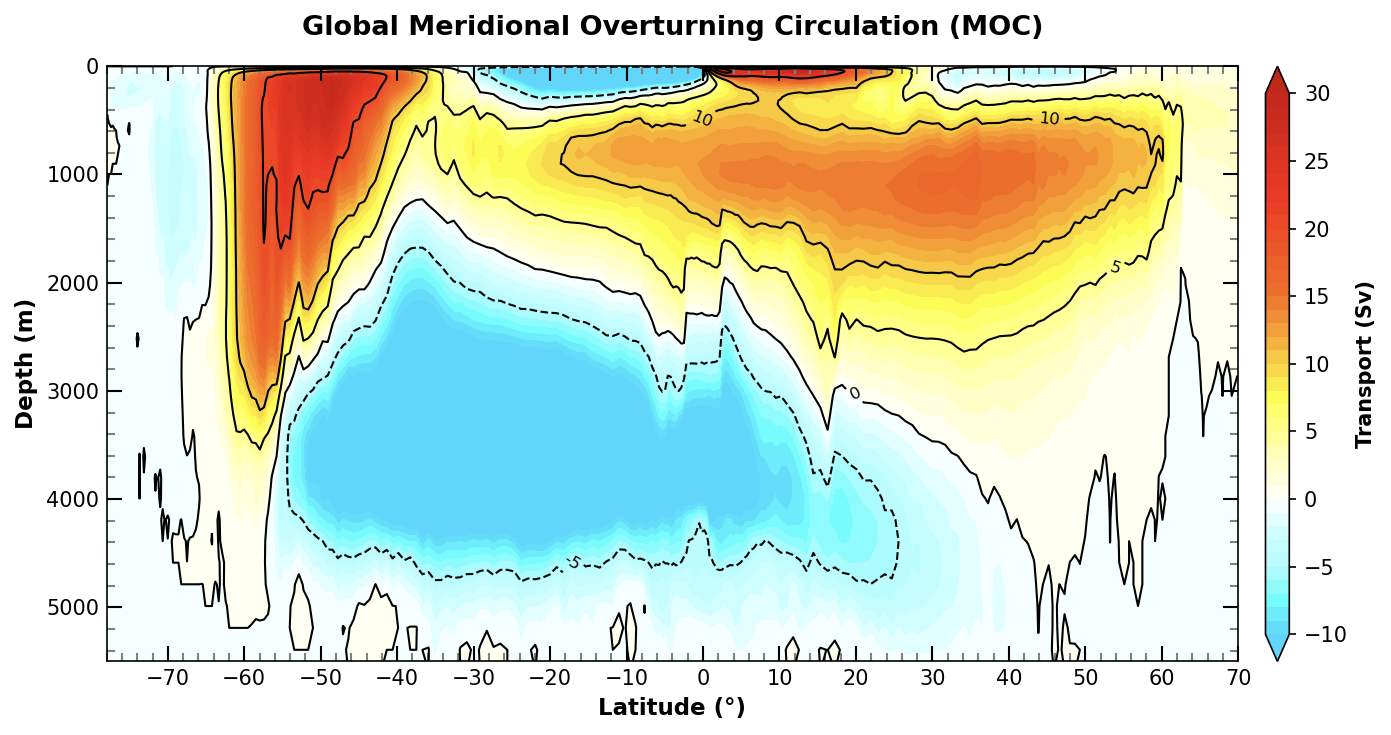

In [11]:

# 1. Define the custom gradient
colors = ["#62D5FB", "#77FBFD", "#B7FBFE", "#CFFDFE", "#FFFFFF", "#FDFF58", "#EC732E", "#EA3A25", "#C0281C"]
my_cmap = mcolors.LinearSegmentedColormap.from_list("AMOC_Cmap", colors)

# Set plotting parameters
vmin = -10; vmax = 30
levels = np.linspace(vmin, vmax, 41)

fig = plt.figure(figsize=(10, 5), dpi=150)
ax = plt.axes()

# 2. Data Preparation
[xx, yy] = np.meshgrid(lat_cut, ds.gdepw_1d.values)
# [xx, yy] = np.meshgrid(moc.gphiv, ds_V.gdepw_1d.values)
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

# Plot filled contours
cf = ax.contourf(xx, yy, moc_mean_cut, levels=levels, 
                 cmap=my_cmap, norm=norm, extend='both')

line_levels = [-5, 0, 5, 10, 20, 30]
cs = ax.contour(xx, yy, moc_mean_cut, levels=line_levels, colors='k', linewidths=1.0)

label_locs = [(-20, 4000), (20, 3000), (0, 600), (45, 1000), (55, 2000)]
ax.clabel(cs, inline=True, fmt='%1.0f', fontsize=8, colors='k', manual=label_locs)

# # Add the 26.5N line
# ax.plot([26.5, 26.5], [0, 5500], color='red', linestyle='--', linewidth=1.5)
# ax.text(27, 5200, '26.5°N', color='red', fontsize=10, fontweight='bold')

# Formatting Axes
ax.set_xlim(-78, 70)
# ax.set_xlim(-78, -35)
ax.set_ylim(5500, 0) 

# --- NEW: Set specific X Ticks ---
ax.set_xticks(np.arange(-70, 71, 10))

# 3. Add Minor Ticks
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

# Style the ticks
ax.tick_params(which='both', width=1, direction='in', top=True, right=True)
ax.tick_params(which='major', length=7)
ax.tick_params(which='minor', length=4, color='gray')

# Colorbar
cbar = plt.colorbar(cf, orientation='vertical', pad=0.02, aspect=25)
cbar.set_label('Transport (Sv)', fontweight='bold')
cbar.set_ticks(np.arange(-10, 35, 5))

# Labels
ax.set_ylabel("Depth (m)", fontsize=11, fontweight='bold')
ax.set_xlabel("Latitude (°)", fontsize=11, fontweight='bold')
ax.set_title("Global Meridional Overturning Circulation (MOC)", fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()


## cdfzonalmean (along i-direction)

/home/vywu/.conda/envs/aste/lib/python3.14/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 42
  result = blockwise(
/home/vywu/.conda/envs/aste/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


Elapsed time: 0.143 minutes


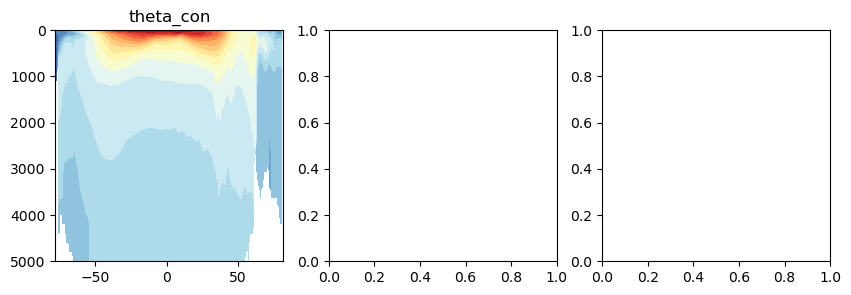

In [13]:

start_time = time.time()
# reload(analysis)

fig, axs = plt.subplots(1, 3, figsize=(10, 3))

dum = analysis.cdfzonalmean(grid, ds, ds.thetao_con)
ss = dum.isel(t=0).values[:,~np.isnan(ii)]; #ss = ss[:,:-35]
axs[0].contourf(xx, yy, ss, 20, cmap='RdYlBu_r')
# axs[0].contour(xx, yy, ss, 20, colors='k')
axs[0].set_title(r"theta_con")
axs[0].set_ylim([5000,0])

# dum = analysis.cdfzonalmean(grid, ds_, xi)
# axs[1].plot(dum.gphif, dum[jk, :])
# axs[1].set_title(r"$\overline{\xi}$")

# dum = analysis.cdfzonalmean(grid, ds_U, ds_U.uoce[:, 1:20, :, :])
# axs[2].contourf(dum.gphiu, -dum.gdept_1d, dum.isel(t=0), cmap="RdBu_r", extend="both")
# axs[2].set_title(r"$\overline{v}$")

print(f"Elapsed time: {(time.time() - start_time)/60:.3f} minutes")


## cdfz2sig (vertical co-ordinate transformation)

Useful subroutine probably, intermediary for doing averaging in density co-ordinates (e.g. `cdfmocsig`).
Can in principle do any co-ordinate transformation (e.g. z -> z).

In [17]:
# Rechunk the vertical dimension so it is in a single chunk
ds = ds.chunk({"z_c": -1})
grid = xgcm.Grid(ds, periodic=False)

In [18]:
# Proceed with your extraction and transformation
theta = ds.thetao_con[0, :, 200, 150]
# theta.plot()

In [19]:
theta.values

array([26.380037 , 26.373987 , 26.362463 , 26.353052 , 26.345642 ,
       26.339283 , 26.333096 , 26.327608 , 26.322912 , 26.318876 ,
       26.3151   , 26.311485 , 26.3076   , 26.301996 , 26.293581 ,
       26.28424  , 26.274317 , 26.258768 , 26.228638 , 26.168308 ,
       26.054775 , 25.842527 , 25.479944 , 24.885748 , 23.744663 ,
       21.535385 , 18.212759 , 15.671275 , 13.894865 , 12.584933 ,
       11.906904 , 11.222732 , 10.703009 , 10.289737 ,  9.940063 ,
        9.644482 ,  9.320742 ,  8.987176 ,  8.554884 ,  8.152157 ,
        7.415273 ,  6.7472544,  6.180806 ,  5.4570675,  5.0865126,
        4.636888 ,  4.246957 ,  3.867522 ,  3.5090432,  3.2159877,
        2.9037719,  2.624383 ,  2.3878958,  2.175222 ,  1.9369078,
        1.8068882,  1.7171491,  1.6499034,  1.5751629,  1.4817655,
        1.3644568,  1.270971 ,  1.2108619,  1.1652921,  1.1138976,
        1.0828456,  1.0558829,  1.0238222,  1.0074157,        nan,
              nan,        nan,        nan,        nan,        

/home/vywu/.conda/envs/aste/lib/python3.14/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: invalid value encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)
/home/vywu/.conda/envs/aste/lib/python3.14/site-packages/xgcm/transform.py:84: RuntimeWarning: divide by zero encountered in log
  target_theta_levels = np.log(target_theta_levels)
/home/vywu/.conda/envs/aste/lib/python3.14/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: invalid value encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)


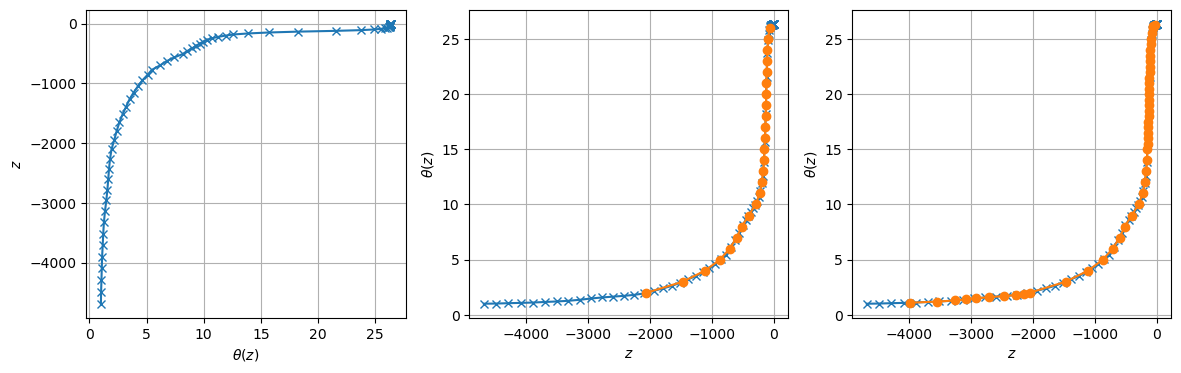

In [20]:
# demonstrating the use of xgcm.transform in the vertical co-ordinate first

# reload(analysis)
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
axs[0].plot(theta, -theta.gdept_1d, 'C0-x')
axs[0].set_xlabel(r"$\theta(z)$")
axs[0].set_ylabel(r"$z$")
axs[0].grid()

theta_coord = np.linspace(0, 30, 31)
z_sigma = analysis.cdfz2sig(grid, ds, -theta.gdept_1d, theta, theta_coord, method='linear')

axs[1].plot(-theta.gdept_1d, theta, 'C0-x')
axs[1].plot(z_sigma, z_sigma.sigma, 'C1-o')
axs[1].set_xlabel(r"$z$")
axs[1].set_ylabel(r"$\theta(z)$")
axs[1].grid()

# artificially stretched coordinate
theta_coord = np.asarray([0, 0.5, 
                          1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9,
                          2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 
                          15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 
                          20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 
                          26.1, 26.2, 26.3, 26.4, 26.5, 26.6, 26.7, 26.8, 26.9, 27.0])
z_sigma = analysis.cdfz2sig(grid, ds, -theta.gdept_1d, theta, theta_coord, method="log")

axs[2].plot(-theta.gdept_1d, theta, 'C0-x')
axs[2].plot(z_sigma, z_sigma.sigma, 'C1-o')
axs[2].set_xlabel(r"$z$")
axs[2].set_ylabel(r"$\theta(z)$")
axs[2].grid()


In [21]:
# Proceed with your extraction and transformation
ds['sigma2'] = xgsw.sigma2(SA=ds.so_abs, CT=ds.thetao_con)
sigma2 = ds.sigma2[0, :, 200, 250]
depth_da = xr.ones_like(sigma2) * (-ds.gdept_1d)
# sigma2.plot()

In [22]:
sigma2.values

array([31.41235251, 31.41419429, 31.41691444, 31.41972886, 31.42223599,
       31.42420207, 31.42608176, 31.42791748, 31.42964365, 31.43133141,
       31.43295561, 31.43453826, 31.4361891 , 31.43822163, 31.44081091,
       31.44471637, 31.45277512, 31.47238214, 31.54677414, 31.65386144,
       31.7856573 , 32.00687903, 32.43124749, 33.07018397, 33.81288187,
       34.50694642, 35.02476557, 35.31041116, 35.38580425, 35.47511618,
       35.49345139, 35.55309167, 35.59583187, 35.64703868, 35.70472306,
       35.78687552, 35.85953851, 35.94589607, 35.99316284, 36.0735415 ,
       36.15496511, 36.23032762, 36.30230691, 36.35144338, 36.42563123,
       36.50301081, 36.55665401, 36.64467813, 36.70957541, 36.76846276,
       36.83960551, 36.88159288, 36.91626991, 36.9432527 , 36.97059336,
       36.99561348, 37.01582812, 37.03006335, 37.04107796, 37.05077875,
       37.06151214, 37.07139769, 37.08226504, 37.0904228 , 37.09690709,
       37.10922703,         nan,         nan,         nan,      

<>:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:55: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:55: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_428574/2929227449.py:38: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  axs[1].set_title("Uniform $\sigma_0$ Spacing")
/tmp/ipykernel_428574/2929227449.py:55: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean 

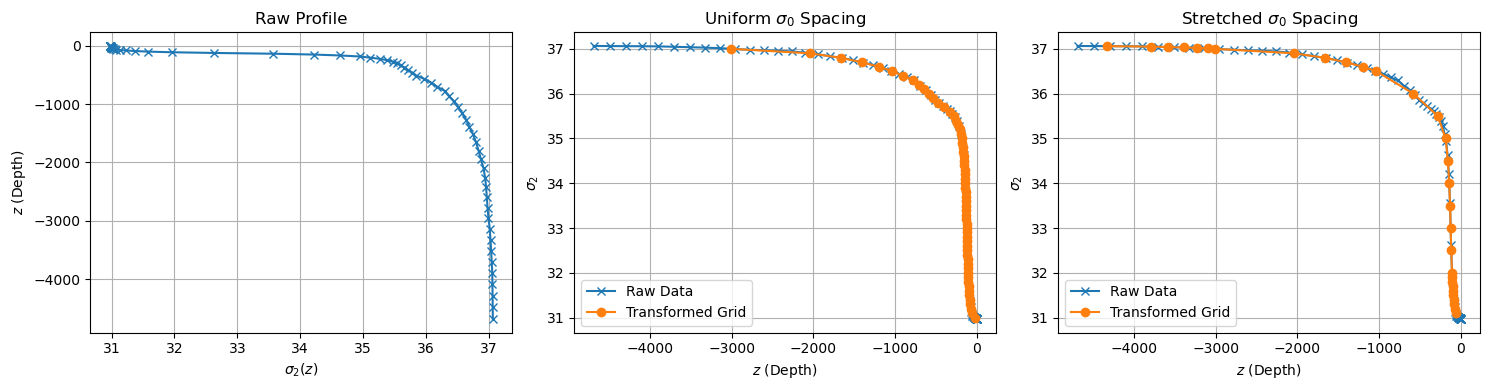

In [23]:

# 1. Calculate Potential Density (sigma2)
ds['sigma2'] = xgsw.sigma2(SA=ds.so_abs, CT=ds.thetao_con)

# 2. Extract slices using dimension names (prevents IndexError)
# Note: Adjust 'y_c' and 'x_c' if your dataset uses 'y' and 'x'
sigma2_slice = ds.sigma2.isel(t=0, y_c=200, x_c=150)
tmask_slice = ds.tmask.isel(y_c=200, x_c=150)  # tmask has no time dimension

# 3. Mask the rock (turn 0s into NaNs) to ensure density is monotonic
sigma2_masked = sigma2_slice.where(tmask_slice == 1)

# 4. Create a depth array that inherits the x_c and y_c coordinates
depth_da = xr.ones_like(sigma2_masked) * (-ds.gdept_1d)

# ==========================================
# PLOTTING AND TRANSFORMATION
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 0: Raw Profile ---
axs[0].plot(sigma2_masked, depth_da, 'C0-x')
axs[0].set_xlabel(r"$\sigma_2(z)$")
axs[0].set_ylabel(r"$z$ (Depth)")
axs[0].set_title("Raw Profile")
axs[0].grid()

# --- Plot 1: Uniform Coordinates ---
# sigma_coord_uniform = np.linspace(22, 28, 61)
sigma_coord_uniform = np.linspace(30, 38, 81)

# Transform: we want to find the depths (depth_da) at specific densities (sigma_coord_uniform)
z_sigma_uniform = analysis.cdfz2sig(grid, ds, depth_da, sigma2_masked, sigma_coord_uniform, method='linear')

axs[1].plot(depth_da, sigma2_masked, 'C0-x', label='Raw Data')
axs[1].plot(z_sigma_uniform, z_sigma_uniform.sigma, 'C1-o', label='Transformed Grid')
axs[1].set_xlabel(r"$z$ (Depth)")
axs[1].set_ylabel(r"$\sigma_2$")
axs[1].set_title("Uniform $\sigma_0$ Spacing")
axs[1].grid()
axs[1].legend()

# --- Plot 2: Artificially Stretched Coordinates ---
sigma_coord_stretch = np.asarray([31.1, 31.2, 31.3, 31.4, 31.5, 31.6, 31.7, 31.8, 31.9, 32.0,
                                  32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 
                                  36.6, 36.7, 36.8, 36.9, 37.0,
                                  37.01, 37.02, 37.03, 37.04, 37.05, 37.06, 37.07, 37.08, 37.09, 
                                  37.1, 37.2, 37.3, 37.4, 37.5, 37.6, 37.7, 37.8, 37.9, 38.0])

z_sigma_stretch = analysis.cdfz2sig(grid, ds, depth_da, sigma2_masked, sigma_coord_stretch, method='linear')

axs[2].plot(depth_da, sigma2_masked, 'C0-x', label='Raw Data')
axs[2].plot(z_sigma_stretch, z_sigma_stretch.sigma, 'C1-o', label='Transformed Grid')
axs[2].set_xlabel(r"$z$ (Depth)")
axs[2].set_ylabel(r"$\sigma_2$")
axs[2].set_title("Stretched $\sigma_0$ Spacing")
axs[2].grid()
axs[2].legend()

plt.tight_layout()
plt.show()


In [24]:
z_sigma

<xarray.DataArray (sigma: 58)> Size: 464B
dask.array<transpose, shape=(58,), dtype=float64, chunksize=(58,), chunktype=numpy.ndarray>
Coordinates:
  * sigma          (sigma) float64 464B 0.0 0.5 1.0 1.1 ... 26.7 26.8 26.9 27.0
    time_centered  datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
    t              datetime64[ns] 8B 1976-01-16T12:00:00
    x_c            int64 8B 150
    y_c            int64 8B 200
    glamt          float64 8B dask.array<chunksize=(), meta=np.ndarray>
    gphit          float64 8B dask.array<chunksize=(), meta=np.ndarray>
Attributes:
    standard_name:  depth
    units:          m
    positive:       down

/home/vywu/.conda/envs/aste/lib/python3.14/site-packages/numba/np/ufunc/gufunc.py:263: RuntimeWarning: invalid value encountered in _interp_1d_linear
  return self.ufunc(*args, **kwargs)


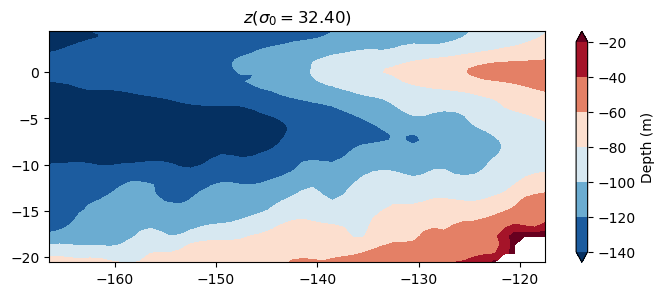

In [25]:
# 1. Extract the 3D chunks safely using .isel()
# y_c = 150 to 200, x_c = 120 to 170
sigma2_3d = ds.sigma2.isel(t=0, y_c=slice(150, 200), x_c=slice(120, 170))
tmask_3d = ds.tmask.isel(y_c=slice(150, 200), x_c=slice(120, 170))

# 2. Mask the rock (0s -> NaNs)
sigma2_masked_3d = sigma2_3d.where(tmask_3d == 1)

# 3. Create the 3D depth array (inherits coords from sigma2_masked_3d)
depth_3d = xr.ones_like(sigma2_masked_3d) * (-ds.gdept_1d)

# 4. Define target coordinates
# sigma_coord = np.linspace(22, 28, 61)
sigma_coord = np.linspace(30, 38, 81)

# 5. Transform 3D Depth onto 3D Sigma
z_sigma = analysis.cdfz2sig(grid, ds, 
                            depth_3d, 
                            sigma2_masked_3d, 
                            sigma_coord, 
                            method='linear')

# ---------------------------------------------------
# PLOTTING
# ---------------------------------------------------
# 6. Extract the 2D Lat/Lon grid from the original dataset for plotting
glamt_slice = ds.glamt.isel(y_c=slice(150, 200), x_c=slice(120, 170))
gphit_slice = ds.gphit.isel(y_c=slice(150, 200), x_c=slice(120, 170))

sigma_ind = 24

fig = plt.figure(figsize=(8, 3))
ax = plt.axes()

# Pass the sliced lat/lon (glamt_slice, gphit_slice) instead of z_sigma.glamt
cs = ax.contourf(glamt_slice, gphit_slice, 
                 z_sigma.isel(sigma=sigma_ind), 
                 cmap="RdBu_r", extend="both")

ax.set_title(r"$z(\sigma_0 = %.2f)$" % z_sigma.sigma[sigma_ind].values)
plt.colorbar(cs, label="Depth (m)")
plt.show()


In [26]:
# random point above that is displayed as nan, and check there are in fact no valid values
# should return as True
all(sigma2_3d[20, 20].values < z_sigma.sigma[sigma_ind].values)

True

## cdfmocsig (averaging in density co-ordinates)

Expects the thickness weighted velocity (i.e. `v * e3v`, a transport, possibly with a factor of `e1v`), which is then transformed into density space conservatively.

* Need to do something about the xgcm warnings about transform being in Grid instad of Axis (kicking out a warning per evaluation at the moment...)

In [45]:

start_time = time.time()

sigma_coord = np.linspace(29, 38, 91)
# kt = slice(0, None)  # if end=None, then takes the whole slice
kt = slice(0, 1)
voce_e3v = (ds.vo.isel(t=kt) + ds.vo_eiv.isel(t=kt)) * ds.e3v_0
voce_e3v = ds.vo.isel(t=kt) * ds.e3v_0
# call routine (vertical transform + compting + averaging in target co-ords)
sigma_moc = analysis.cdfsigmamoc(grid, ds,
                                 voce_e3v,
                                 ds.sigma2.isel(t=kt), 
                                 # ds.thetao_con.mean(dim="t"),
                                 sigma_coord,
                                 disp=False)

voce_eiv_e3v = ds.vo_eiv.isel(t=kt) * ds.e3v_0
sigma_eiv_moc = analysis.cdfsigmamoc(grid, ds, 
                                     voce_eiv_e3v, 
                                     ds.sigma2.isel(t=kt),
                                     # ds.thetao_con.mean(dim="t"),
                                     sigma_coord,
                                     disp=False)

print(f"Elapsed time: {(time.time() - start_time)/60:.3f} minutes")


routine can be costly and a bit slow, have disp=True to display some progress
 
routine can be costly and a bit slow, have disp=True to display some progress
 
Elapsed time: 0.014 minutes


In [52]:
vec = np.arange

array([0, 1])

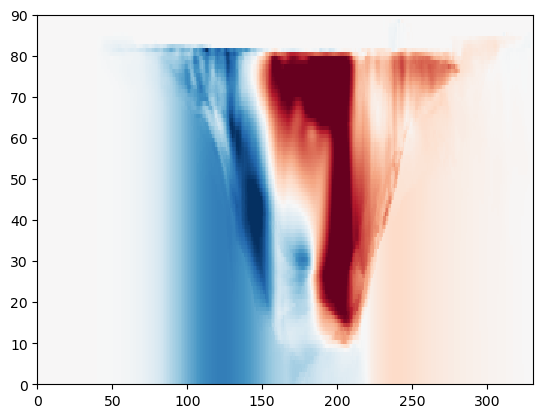

In [56]:
plt.pcolor(sigma_moc.values, cmap="RdBu_r", vmin=-40, vmax=40)

In [71]:
# # do a writeout then re-read

# in_out.save_netcdf(sigma_moc, varname="sigma_moc", filename="sigma_moc.nc")
# in_out.save_netcdf(sigma_eiv_moc, varname="sigma_eiv_moc", filename="sigma_eiv_moc.nc")

# del sigma_moc, sigma_eiv_moc

# sigma_moc = xr.open_dataset("sigma_moc.nc")
# sigma_eiv_moc = xr.open_dataset("sigma_eiv_moc.nc")

variable name sigma_moc, output to sigma_moc.nc
variable name sigma_eiv_moc, output to sigma_eiv_moc.nc


In [28]:
ii = ds.gphiv.values * ds.tmask.isel(z_c=0)
ii=ii.values; ii[ii==0]=np.nan
ii = np.nanmean(ii, axis=1)
lat_cut = ii[~np.isnan(ii)]

/tmp/ipykernel_428574/4039680429.py:3: RuntimeWarning: Mean of empty slice
  ii = np.nanmean(ii, axis=1)


In [29]:

start_time = time.time()

# reload(analysis)
sigma_moc = sigma_moc.compute()
sigma_moc_cut = sigma_moc[:,~np.isnan(ii)]

sigma_eiv_moc = sigma_eiv_moc.compute()
sigma_eiv_moc_cut = sigma_eiv_moc[:,~np.isnan(ii)]

z_moc = analysis.cdfmoc(grid=grid, ds=ds, voce_e3v=ds.vo.mean(dim="t") * ds.e3v.mean(dim="t"))
z_moc_cut = z_moc[:,~np.isnan(ii)]

print(f"Elapsed time: {(time.time() - start_time)/60:.3f} minutes")


Elapsed time: 4.941 minutes


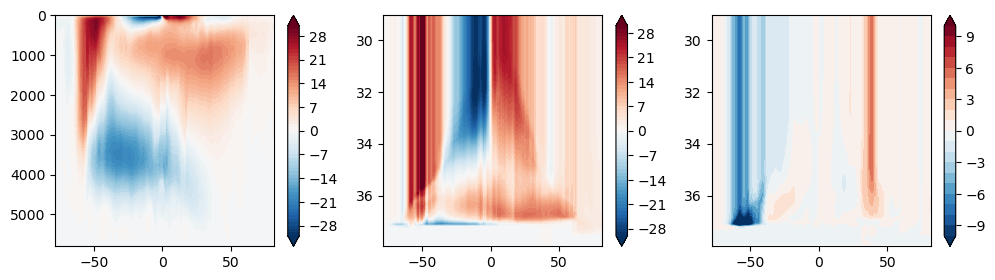

In [32]:

# MOC in both co-ordinates for comparison
fig = plt.figure(figsize=(12, 3))

[xx, yy] = np.meshgrid(lat_cut, ds.gdepw_1d.values)
ax = plt.subplot(1, 3, 1) 
cs = ax.contourf(xx, yy, z_moc_cut,
                 levels=np.linspace(-31, 31, 63), cmap="RdBu_r", extend="both") 
ax.set_ylim(ds.gdepw_1d.values.max(), ds.gdepw_1d.values.min())
plt.colorbar(cs)

ax = plt.subplot(1, 3, 2)
[xx, yy] = np.meshgrid(lat_cut, sigma_coord[:-1])
cs = ax.contourf(xx, yy, sigma_moc_cut,
                 levels=np.linspace(-30, 30, 61), cmap="RdBu_r", extend="both") 
# ax.set_xlim(-20, 70); #ax.set_ylim(37.4, 29.7)
ax.set_ylim(sigma_moc.sigma.max(), sigma_moc.sigma.min())
plt.colorbar(cs)

ax = plt.subplot(1, 3, 3)
cs = ax.contourf(xx, yy, sigma_eiv_moc_cut,
                 levels=np.linspace(-10, 10, 21), cmap="RdBu_r", extend="both") 
# ax.set_xlim(-20, 70)
ax.set_ylim(sigma_moc.sigma.max(), sigma_moc.sigma.min())
plt.colorbar(cs)


In [33]:
from scipy.interpolate import interp1d

# --- 1. PREP: Calculate depth of each Sigma bin ---
# Use the mean depth profile of your sigma variable (ds.sigma2)
sigma_var = ds.sigma2.mean(dim=['x_c', 'y_c', 't']) # Average density profile (90 levels)
z_ref = ds.gdept_1d.values                          # Standard depth levels (75 levels)

# Create an interpolator: density -> depth
# This tells roughly at what depth each sigma value is found
f_sigma_to_z = interp1d(sigma_var.values, z_ref, kind='linear', 
                        bounds_error=False, fill_value=np.nan)

# Calculate depth for each of your 90 sigma levels
depths_of_sigma = f_sigma_to_z(sigma_coord) # This is now 90 levels long!

# --- 2. PREP: Initialize Remapping ---
# z_depths is our common "target" grid for the plot
z_depths = np.linspace(0, 5000, 200) 
moc_remapped = np.zeros((len(z_depths), len(lat_cut)))

# --- 3. LOOP: Vertical Interpolation ---
# sigma_moc_cut is (sigma: 90, lat: len(lat_cut))
for i in range(len(lat_cut)):
    depths = depths_of_sigma # The depth of the 90 sigma bins
    depths = depths[:-1]
    values = sigma_moc_cut[:, i].values # The MOC values at those bins
    
    # Clean mask: remove NaNs so interpolation doesn't crash
    mask = ~np.isnan(depths) & ~np.isnan(values)
    d_clean = depths[mask]
    v_clean = values[mask]
    
    # Interpolation needs strictly increasing depths
    sort_idx = np.argsort(d_clean)
    d_sorted = d_clean[sort_idx]
    v_sorted = v_clean[sort_idx]
    
    # Interpolate from Sigma-Depth to Target Depth (z_depths)
    f = interp1d(d_sorted, v_sorted, kind='linear', bounds_error=False, fill_value=0)
    moc_remapped[:, i] = f(z_depths)

# --- 4. FORMAT: Convert back to Xarray for easy plotting ---
moc_z_space = xr.DataArray(
    moc_remapped,
    coords={'depth': z_depths, 'lat': lat_cut},
    dims=('depth', 'lat')
)


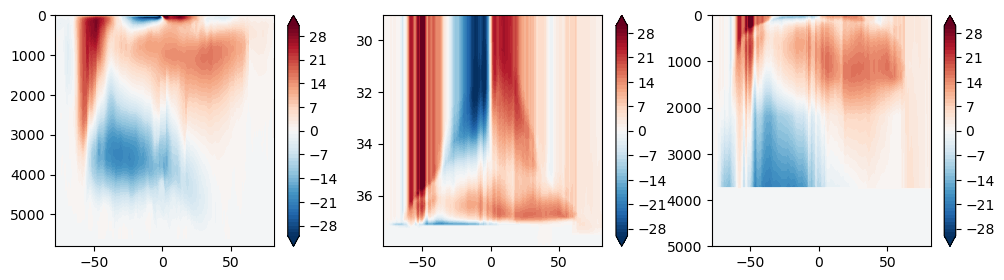

In [34]:

# MOC in both co-ordinates for comparison
fig = plt.figure(figsize=(12, 3))

[xx, yy] = np.meshgrid(lat_cut, ds.gdepw_1d.values)
ax = plt.subplot(1, 3, 1) 
cs = ax.contourf(xx, yy, z_moc_cut,
                 levels=np.linspace(-31, 31, 63), cmap="RdBu_r", extend="both") 
ax.set_ylim(ds.gdepw_1d.values.max(), ds.gdepw_1d.values.min())
plt.colorbar(cs)

ax = plt.subplot(1, 3, 2)
[xx, yy] = np.meshgrid(lat_cut, sigma_coord[:-1])
cs = ax.contourf(xx, yy, sigma_moc_cut,
                 levels=np.linspace(-30, 30, 61), cmap="RdBu_r", extend="both") 
# ax.set_xlim(-20, 70); #ax.set_ylim(37.4, 29.7)
ax.set_ylim(sigma_moc.sigma.max(), sigma_moc.sigma.min())
plt.colorbar(cs)

ax = plt.subplot(1, 3, 3)
[xx, yy] = np.meshgrid(lat_cut, moc_z_space.depth.values)
cs = ax.contourf(xx, yy, moc_z_space,
                 levels=np.linspace(-30, 30, 61), cmap="RdBu_r", extend="both") 
# ax.set_xlim(-20, 70)
ax.set_ylim(moc_z_space.depth.max(), moc_z_space.depth.min())
plt.colorbar(cs)
